***1.Install required Python libraries***

In [1]:
!pip install yfinance numpy pandas scipy matplotlib

***2.We define a 30-stock universe across sectors.***

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

tickers = [
    "AAPL","MSFT","GOOGL","AMZN","TSLA",
    "NVDA","META","NFLX","AMD","INTC",
    "JPM","BAC","GS","C","WFC",
    "JNJ","PFE","MRK","UNH","ABBV",
    "XOM","CVX","COP","OXY","BP",
    "PG","KO","PEP","WMT","DIS"
]

***3.Download historical stock data using Yahoo Finance API***

In [4]:
start_date = "2026-01-01"
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

data = yf.download(tickers, start=start_date, end=end_date)["Close"]


data = data.dropna(axis=1)

returns = data.pct_change().dropna()

data.head()

/tmp/ipykernel_4027/3186534030.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)["Close"]
[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,ABBV,AMD,AMZN,BAC,BP,C,COP,CVX,DIS,...,NVDA,OXY,PEP,PFE,PG,TSLA,UNH,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-02,270.756653,225.608078,223.470001,226.500000,55.635487,35.371681,117.528542,95.953278,154.389694,111.849998,...,188.839783,42.179729,140.970551,24.765158,139.738144,438.070007,333.804901,94.734390,112.529060,121.837906
2026-01-05,267.010162,216.625473,221.080002,233.059998,56.570198,35.657967,122.083145,98.433975,162.262695,114.070000,...,188.109818,41.035164,138.681015,24.755322,138.338684,451.670013,339.381531,95.908623,112.479164,124.529961
2026-01-06,262.114716,220.314926,214.350006,240.929993,56.928177,33.920483,121.291039,96.360115,155.023499,114.570000,...,187.229874,41.542755,137.729523,25.011040,137.885361,432.959991,346.277924,95.918571,114.105820,120.248505
2026-01-07,260.086609,229.651718,210.020004,241.559998,55.327225,33.239307,120.172195,93.214600,153.696487,112.910004,...,189.099762,40.796299,135.796768,24.863510,136.042419,431.410004,339.064026,93.828850,112.489143,117.705444
2026-01-08,258.797852,220.511703,204.679993,246.289993,55.864193,33.693424,119.409782,97.957680,157.707245,114.169998,...,185.029984,43.025711,138.135880,24.873346,139.481903,435.799988,344.174286,95.132439,112.838425,122.096184


***4.We rank stocks by a simplified Sharpe ratio and select top 10.***

In [5]:
mean_returns = returns.mean()
std_returns = returns.std()

sharpe_like = mean_returns / std_returns

top10_tickers = sharpe_like.sort_values(ascending=False).head(10).index.tolist()

print("Selected 10 stocks:", top10_tickers)

Selected 10 stocks: ['INTC', 'OXY', 'BP', 'CVX', 'COP', 'XOM', 'KO', 'AMD', 'GOOGL', 'AMZN']


***5.We optimize portfolio weights using Mean-Variance Optimization.***

In [9]:
selected_returns = returns[top10_tickers]

mean_returns = selected_returns.mean()
cov_matrix = selected_returns.cov()

def portfolio_performance(weights):
    ret = np.dot(weights, mean_returns) * 252
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))
    return ret, vol

def negative_sharpe(weights):
    ret, vol = portfolio_performance(weights)
    return -ret / vol

num_assets = len(top10_tickers)
init_guess = num_assets * [1./num_assets]

bounds = tuple((0.05, 0.5) for _ in range(num_assets))
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

result = minimize(
    negative_sharpe,
    init_guess,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

weights = result.x

for i, t in enumerate(top10_tickers):
    print(t, ":", round(weights[i], 3))

INTC : 0.079
OXY : 0.139
BP : 0.05
CVX : 0.134
COP : 0.05
XOM : 0.05
KO : 0.207
AMD : 0.05
GOOGL : 0.117
AMZN : 0.123


***6.Rolling Window***

In [11]:
rolling_returns = []

window_size = 5

def optimize_portfolio(mean_returns_df, cov_matrix_df):
    def negative_sharpe_local(weights):
        ret = np.dot(weights, mean_returns_df) * 252
        vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix_df * 252, weights)))
        return -ret / vol

    num_assets_local = len(mean_returns_df)
    init_guess_local = num_assets_local * [1./num_assets_local]

    # Using global bounds and constraints already defined in 09EYLQ3EzS03
    result_local = minimize(
        negative_sharpe_local,
        init_guess_local,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    return result_local.x

for i in range(window_size, len(returns)):

    window_data = returns.iloc[i-window_size:i][top10_tickers]

    mean_ret = window_data.mean()
    cov_mat = window_data.cov()

    weights = optimize_portfolio(mean_ret, cov_mat)

    next_day_return = np.dot(weights, returns.iloc[i][top10_tickers])

    rolling_returns.append(next_day_return)

rolling_returns = pd.Series(rolling_returns)

***7.Compare portfolio performance with S&P 500 benchmark***

/tmp/ipykernel_4027/236290844.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start=start_date, end=end_date)["Close"]
[*********************100%***********************]  1 of 1 completed


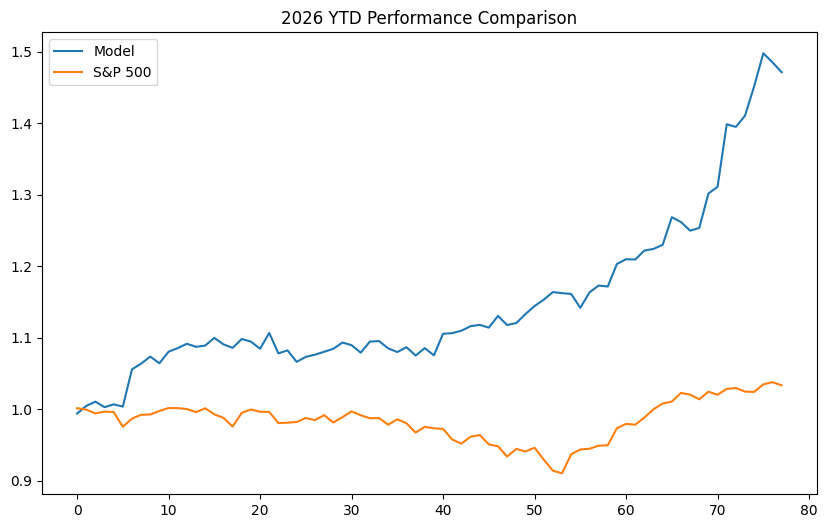

In [13]:
sp500 = yf.download("^GSPC", start=start_date, end=end_date)["Close"]
sp500_returns = sp500.pct_change().dropna()


min_len = min(len(rolling_returns), len(sp500_returns))
rolling_returns = rolling_returns[-min_len:]
sp500_returns = sp500_returns[-min_len:]

cum_model = (1 + rolling_returns).cumprod()
cum_sp500 = (1 + sp500_returns).cumprod()

plt.figure(figsize=(10,6))
plt.plot(cum_model, label="Model")
plt.plot(cum_sp500.values, label="S&P 500")
plt.legend()
plt.title("2026 YTD Performance Comparison")
plt.show()

***8.Rolling Performance***

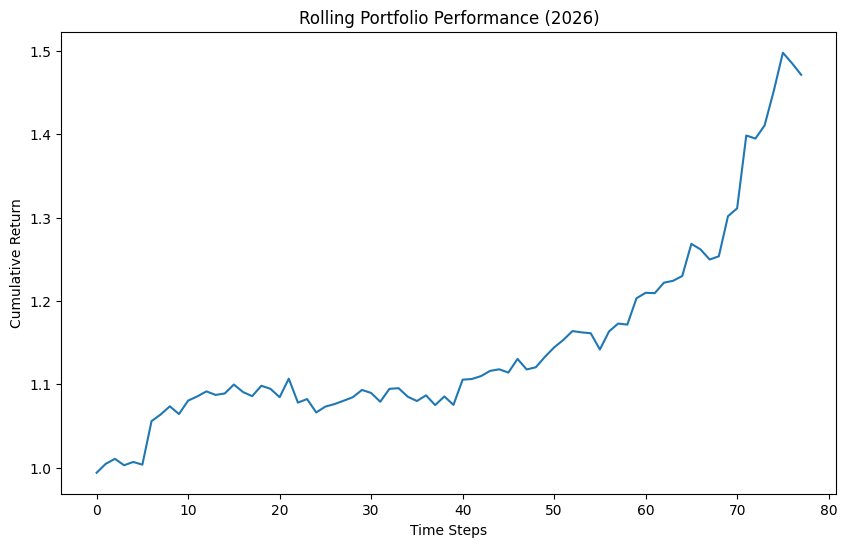

In [14]:
plt.figure(figsize=(10,6))
plt.plot((1 + rolling_returns).cumprod())
plt.title("Rolling Portfolio Performance (2026)")
plt.xlabel("Time Steps")
plt.ylabel("Cumulative Return")
plt.show()

***I used Modern Portfolio Theory to select and optimize a 10-stock portfolio, maximizing Sharpe ratio, and compared it with the S&P 500 using historical backtesting.***

In [15]:
plt.savefig("portfolio.png")

<Figure size 640x480 with 0 Axes>